# Regresión Lineal Múltiple

La **regresión lineal múltiple** (RLM) es una de las herramientas más fundamentales en estadística aplicada y econometría. Permite modelar la relación entre una variable dependiente cuantitativa y **dos o más variables independientes**, capturando el efecto parcial de cada predictor manteniendo los demás constantes.

## Objetivos

- Formular el modelo de regresión lineal múltiple en notación vectorial y matricial.
- Comprender los supuestos de Gauss-Markov que garantizan las propiedades del estimador.
- Derivar el estimador de mínimos cuadrados ordinarios (MCO) algebraicamente.
- Demostrar las propiedades del estimador MCO (MELI / BLUE).
- Obtener el estimador de máxima verosimilitud y su relación con MCO.
- Construir e interpretar la tabla ANOVA de la regresión.
- Medir la bondad de ajuste con $R^2$ y $R^2$ ajustado.
- Realizar e interpretar pruebas de hipótesis sobre los coeficientes.

---
**Ejemplo motivador:** Una empresa de consumo masivo quiere saber cómo el gasto en publicidad en televisión, radio y medios digitales impacta sus ventas semanales. ¿Cuánto aporta cada canal? ¿El modelo en su conjunto es útil?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
# ─── Generación del dataset de ejemplo ───────────────────────────────────────
# Empresa de consumo masivo: gasto semanal (miles USD) en tres canales
# Ventas semanales (miles de unidades)

np.random.seed(42)
n = 150

TV      = np.random.uniform(10, 300, n)      # gasto en TV
Radio   = np.random.uniform(5,  50,  n)      # gasto en radio
Digital = np.random.uniform(0,  100, n)      # gasto en medios digitales
epsilon = np.random.normal(0,   3,   n)      # error aleatorio

# Modelo poblacional verdadero: Ventas = 5 + 0.045*TV + 0.18*Radio + 0.12*Digital + ε
Ventas  = 5 + 0.045*TV + 0.18*Radio + 0.12*Digital + epsilon

df = pd.DataFrame({
    'TV':      TV,
    'Radio':   Radio,
    'Digital': Digital,
    'Ventas':  Ventas
})

print(f"Dimensiones del dataset: {df.shape}")
df.head(8)

Dimensiones del dataset: (150, 4)


,TV,Radio,Digital,Ventas
0,118.6166,45.8720,5.1682,20.1476
1,285.7071,15.7803,53.1355,31.4996
2,222.2782,11.5203,54.0635,26.1368
3,183.6110,27.0254,63.7430,25.2964
4,55.2454,49.3543,72.6091,25.0259
5,55.2384,15.8925,97.5852,19.0490
6,26.8442,35.2461,51.6300,18.6924
7,261.1911,39.2729,32.2956,26.8322


In [3]:
# Estadísticas descriptivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,150.0000,147.1373,85.9939,11.6014,72.2866,139.9523,227.4019,296.1972
Radio,150.0000,28.2885,13.1135,5.2278,16.1365,30.0200,39.1027,49.5524
Digital,150.0000,49.6152,30.1338,1.0838,24.8359,50.4194,75.3127,99.0505
Ventas,150.0000,22.7364,6.1766,5.4420,19.0357,23.5500,27.0053,35.4455


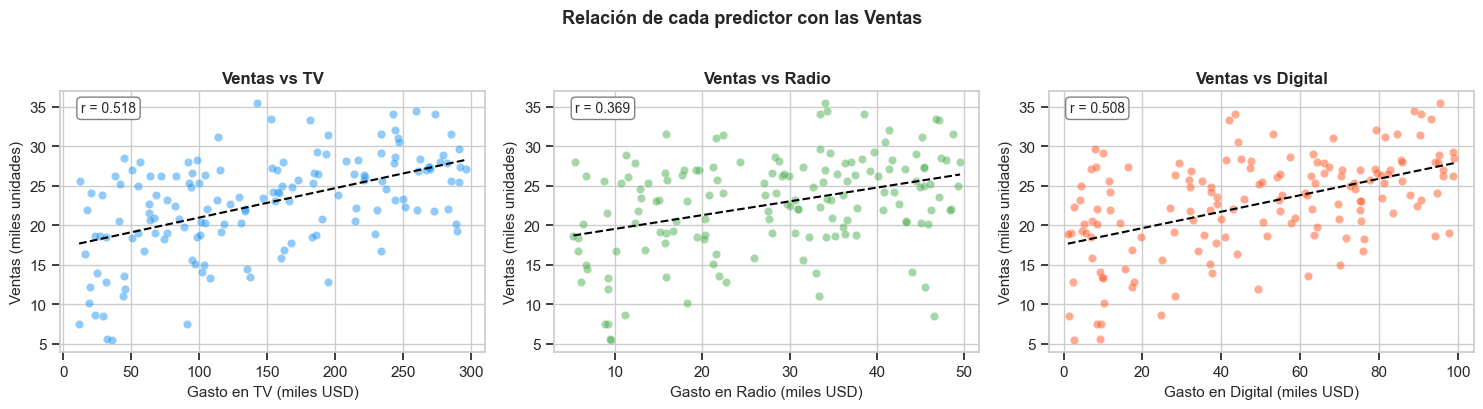

In [4]:
# Visualización de relaciones bivariadas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
variables = ['TV', 'Radio', 'Digital']
colores   = ['#2196F3', '#4CAF50', '#FF5722']

for ax, var, col in zip(axes, variables, colores):
    ax.scatter(df[var], df['Ventas'], alpha=0.5, color=col, edgecolors='white', linewidths=0.3)
    m, b = np.polyfit(df[var], df['Ventas'], 1)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    ax.plot(x_line, m*x_line + b, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel(f'Gasto en {var} (miles USD)', fontsize=11)
    ax.set_ylabel('Ventas (miles unidades)', fontsize=11)
    ax.set_title(f'Ventas vs {var}', fontsize=12, fontweight='bold')
    r = np.corrcoef(df[var], df['Ventas'])[0, 1]
    ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))

plt.suptitle('Relación de cada predictor con las Ventas', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 1. El Modelo de Regresión Lineal Múltiple

### 1.1. Especificación escalar

El modelo de regresión lineal múltiple relaciona una variable dependiente $y$ con $k$ variables independientes $x_1, x_2, \ldots, x_k$ mediante:

$$y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_k x_{ik} + \varepsilon_i, \quad i = 1, 2, \ldots, n$$

donde:
- $y_i$: valor observado de la variable dependiente para la observación $i$.
- $x_{ij}$: valor del $j$-ésimo regresor para la observación $i$.
- $\beta_0$: intercepto (valor esperado de $y$ cuando todas las $x_j = 0$).
- $\beta_j$: efecto **parcial** de $x_j$ sobre $y$, manteniendo los demás regresores constantes (*ceteris paribus*).
- $\varepsilon_i$: término de error aleatorio no observable.

### 1.2. Notación matricial

Para $n$ observaciones y $k$ predictores, el modelo completo se escribe en forma compacta como:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

donde:

$$\mathbf{y} = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix}_{n \times 1}, \quad \mathbf{X} = \begin{pmatrix} 1 & x_{11} & \cdots & x_{1k} \\ 1 & x_{21} & \cdots & x_{2k} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & \cdots & x_{nk} \end{pmatrix}_{n \times (k+1)}, \quad \boldsymbol{\beta} = \begin{pmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_k \end{pmatrix}_{(k+1) \times 1}, \quad \boldsymbol{\varepsilon} = \begin{pmatrix} \varepsilon_1 \\ \varepsilon_2 \\ \vdots \\ \varepsilon_n \end{pmatrix}_{n \times 1}$$

La columna de unos en $\mathbf{X}$ corresponde al intercepto $\beta_0$.

### 1.3. Interpretación de los coeficientes

> **$\beta_j$ mide el cambio promedio esperado en $y$ ante un aumento unitario de $x_j$, manteniendo constantes el resto de las variables.**

En nuestro ejemplo de publicidad:
- $\hat{\beta}_{\text{TV}} = 0.045$: cada mil USD adicionales en TV se asocian con **45 unidades más de ventas**, dado el gasto en Radio y Digital.
- $\hat{\beta}_{\text{Radio}} = 0.18$: mayor retorno marginal por unidad invertida.
- $\hat{\beta}_{\text{Digital}} = 0.12$: efecto intermedio.

In [5]:
# ─── Construcción explícita de la matriz de diseño X ────────────────────────
X_cols = ['TV', 'Radio', 'Digital']

# Agregar columna de unos para el intercepto
X_matrix = np.column_stack([np.ones(n), df[X_cols].values])
y_vector  = df['Ventas'].values

print("Forma de la matriz de diseño X:", X_matrix.shape)   # (150, 4)
print("Forma del vector y:            ", y_vector.shape)   # (150,)
print()
print("Primeras 5 filas de X:")
print(pd.DataFrame(X_matrix[:5], columns=['Intercepto', 'TV', 'Radio', 'Digital']).to_string(index=False))

Forma de la matriz de diseño X: (150, 4)
Forma del vector y:             (150,)

Primeras 5 filas de X:
 Intercepto       TV   Radio  Digital
     1.0000 118.6166 45.8720   5.1682
     1.0000 285.7071 15.7803  53.1355
     1.0000 222.2782 11.5203  54.0635
     1.0000 183.6110 27.0254  63.7430
     1.0000  55.2454 49.3543  72.6091


---

## 2. Supuestos del Modelo

Los supuestos clásicos (conocidos como condiciones de **Gauss-Markov**) son las condiciones bajo las cuales el estimador MCO es el mejor estimador lineal insesgado.

### Supuesto 1: Linealidad en los parámetros

El modelo es lineal en los parámetros $\boldsymbol{\beta}$ (no necesariamente lineal en las variables $x$):

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

Esto permite transformaciones como $\log(x)$, $x^2$, interacciones $x_1 \cdot x_2$, etc.

### Supuesto 2: Muestra aleatoria (exogeneidad estricta)

$$E[\boldsymbol{\varepsilon} \mid \mathbf{X}] = \mathbf{0}$$

El error esperado es cero para cualquier valor de los regresores. Implica que ninguna variable relevante fue omitida y que no hay sesgo de selección.

### Supuesto 3: No multicolinealidad perfecta

La matriz $\mathbf{X}$ tiene **rango completo**: $\text{rk}(\mathbf{X}) = k + 1$.

Esto garantiza que $(\mathbf{X}^T\mathbf{X})^{-1}$ existe y los coeficientes son identificables. La multicolinealidad *imperfecta* infla las varianzas.

### Supuesto 4: Homocedasticidad

$$\text{Var}(\varepsilon_i \mid \mathbf{X}) = \sigma^2 \quad \forall\, i$$

La varianza del error es constante. Su violación (heterocedasticidad) no introduce sesgo pero sí invalida los errores estándar estándar.

### Supuesto 5: No autocorrelación

$$\text{Cov}(\varepsilon_i, \varepsilon_j \mid \mathbf{X}) = 0, \quad i \neq j$$

Los errores de distintas observaciones no están correlacionados entre sí. Frecuentemente violado en datos de series de tiempo.

### Supuesto 6: Normalidad de los errores (para inferencia)

$$\boldsymbol{\varepsilon} \mid \mathbf{X} \sim \mathcal{N}(\mathbf{0},\, \sigma^2 \mathbf{I}_n)$$

Necesario para que las estadísticas $t$ y $F$ sigan sus distribuciones exactas en muestras pequeñas. En muestras grandes el TCL lo garantiza de forma asintótica.

Los supuestos 1-5 son suficientes para demostrar que el estimador MCO es MELI (Mejor Estimador Lineal Insesgado). El supuesto 6 es adicional para la inferencia exacta.

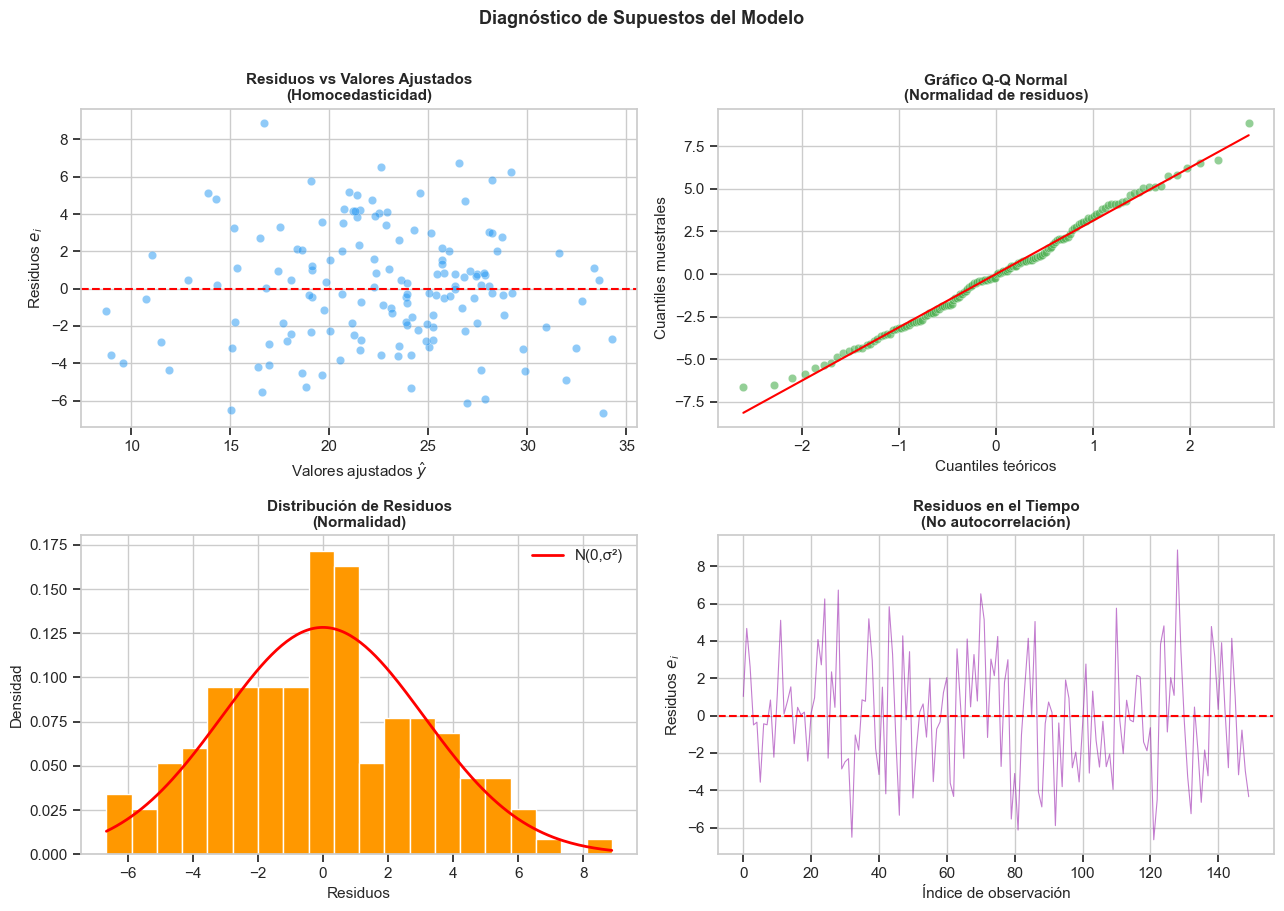

Shapiro-Wilk: W = 0.9920, p-valor = 0.5605
→ Residuos con distribución normal


In [6]:
# ─── Verificación visual de supuestos (con el modelo ajustado previamente) ──
# Ajustamos el modelo con statsmodels para obtener residuos
X_sm  = sm.add_constant(df[['TV', 'Radio', 'Digital']])
model = sm.OLS(df['Ventas'], X_sm).fit()

residuos  = model.resid
ajustados = model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Residuos vs Ajustados (homocedasticidad)
axes[0, 0].scatter(ajustados, residuos, alpha=0.5, color='#2196F3', edgecolors='white', linewidths=0.3)
axes[0, 0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0, 0].set_xlabel('Valores ajustados $\\hat{y}$', fontsize=11)
axes[0, 0].set_ylabel('Residuos $e_i$', fontsize=11)
axes[0, 0].set_title('Residuos vs Valores Ajustados\n(Homocedasticidad)', fontsize=11, fontweight='bold')

# 2. Q-Q plot (normalidad)
(osm, osr), (slope, intercept, r) = stats.probplot(residuos)
axes[0, 1].scatter(osm, osr, alpha=0.6, color='#4CAF50', edgecolors='white', linewidths=0.3)
x_line = np.array([osm[0], osm[-1]])
axes[0, 1].plot(x_line, slope * x_line + intercept, color='red', linewidth=1.5)
axes[0, 1].set_xlabel('Cuantiles teóricos', fontsize=11)
axes[0, 1].set_ylabel('Cuantiles muestrales', fontsize=11)
axes[0, 1].set_title('Gráfico Q-Q Normal\n(Normalidad de residuos)', fontsize=11, fontweight='bold')

# 3. Histograma de residuos
axes[1, 0].hist(residuos, bins=20, color='#FF9800', edgecolor='white', density=True)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[1, 0].plot(xr, stats.norm.pdf(xr, 0, residuos.std()), 'r-', linewidth=2, label='N(0,σ²)')
axes[1, 0].set_xlabel('Residuos', fontsize=11)
axes[1, 0].set_ylabel('Densidad', fontsize=11)
axes[1, 0].set_title('Distribución de Residuos\n(Normalidad)', fontsize=11, fontweight='bold')
axes[1, 0].legend()

# 4. Residuos vs índice (autocorrelación)
axes[1, 1].plot(range(len(residuos)), residuos, alpha=0.6, color='#9C27B0', linewidth=0.8)
axes[1, 1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1, 1].set_xlabel('Índice de observación', fontsize=11)
axes[1, 1].set_ylabel('Residuos $e_i$', fontsize=11)
axes[1, 1].set_title('Residuos en el Tiempo\n(No autocorrelación)', fontsize=11, fontweight='bold')

plt.suptitle('Diagnóstico de Supuestos del Modelo', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Test de Shapiro-Wilk para normalidad
stat, p_sw = stats.shapiro(residuos)
print(f"Shapiro-Wilk: W = {stat:.4f}, p-valor = {p_sw:.4f}")
print("→ Residuos con distribución normal" if p_sw > 0.05 else "→ Evidencia contra normalidad")

In [7]:
# ─── Factor de Inflación de Varianza (VIF) — multicolinealidad ──────────────
X_vif = df[['TV', 'Radio', 'Digital']].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    'Variable': ['TV', 'Radio', 'Digital'],
    'VIF': [variance_inflation_factor(X_vif.values, i+1) for i in range(3)]
})

print("Factor de Inflación de Varianza (VIF)")
print("VIF > 10 → multicolinealidad problemática")
print()
display(vif_data)

# Matriz de correlaciones
print("\nMatriz de correlaciones entre predictores:")
display(df[['TV', 'Radio', 'Digital']].corr().round(3))

Factor de Inflación de Varianza (VIF)
VIF > 10 → multicolinealidad problemática



,Variable,VIF
0,TV,1.0199
1,Radio,1.0023
2,Digital,1.0200



Matriz de correlaciones entre predictores:


,TV,Radio,Digital
TV,1.0000,0.0360,-0.1360
Radio,0.0360,1.0000,-0.0370
Digital,-0.1360,-0.0370,1.0000


---

## 3. Mínimos Cuadrados Ordinarios (MCO)

### 3.1. Principio

El estimador MCO minimiza la **suma de cuadrados de los residuos** (SCR):

$$\text{SCR}(\boldsymbol{\beta}) = \sum_{i=1}^{n} e_i^2 = \boldsymbol{e}^T \boldsymbol{e} = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

donde $e_i = y_i - \hat{y}_i$ son los **residuos** (diferencia entre observado y ajustado).

### 3.2. Derivación de las ecuaciones normales

Expandiendo la función de costo:

$$\text{SCR} = \mathbf{y}^T\mathbf{y} - 2\boldsymbol{\beta}^T\mathbf{X}^T\mathbf{y} + \boldsymbol{\beta}^T\mathbf{X}^T\mathbf{X}\boldsymbol{\beta}$$

Tomando la derivada con respecto a $\boldsymbol{\beta}$ e igualando a cero:

$$\frac{\partial\,\text{SCR}}{\partial\,\boldsymbol{\beta}} = -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{0}$$

Esto produce las **ecuaciones normales**:

$$\mathbf{X}^T\mathbf{X}\,\hat{\boldsymbol{\beta}} = \mathbf{X}^T\mathbf{y}$$

### 3.3. Solución cerrada

Si $\mathbf{X}^T\mathbf{X}$ es invertible (rango completo, supuesto 3):

$$\boxed{\hat{\boldsymbol{\beta}}_{\text{MCO}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}}$$

Los valores ajustados son:

$$\hat{\mathbf{y}} = \mathbf{X}\hat{\boldsymbol{\beta}} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y} = \mathbf{H}\mathbf{y}$$

donde $\mathbf{H} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$ se llama **matriz sombrero** (*hat matrix*) o matriz de proyección. Es idempotente: $\mathbf{H}^2 = \mathbf{H}$, $\mathbf{H}^T = \mathbf{H}$.

### 3.4. Estimación de $\sigma^2$

La varianza del error se estima de forma insesgada mediante:

$$\hat{\sigma}^2 = s^2 = \frac{\text{SCR}}{n - k - 1} = \frac{\mathbf{e}^T\mathbf{e}}{n - k - 1}$$

donde $n - k - 1$ son los **grados de libertad del error** ($n$ datos menos $k+1$ parámetros estimados).

In [8]:
# ─── MCO desde cero: álgebra matricial pura ─────────────────────────────────
X = X_matrix   # (150, 4) — incluye columna de unos
y = y_vector   # (150,)

# Paso 1: X'X
XtX = X.T @ X
print("X'X (4×4):")
print(pd.DataFrame(XtX, columns=['const','TV','Radio','Digital'],
                   index=['const','TV','Radio','Digital']).round(2))
print()

X'X (4×4):
             const           TV       Radio      Digital
const     150.0000   22070.5900   4243.2700    7442.2900
TV      22070.5900 4349254.6900 630340.7600 1042368.8300
Radio    4243.2700  630340.7600 145658.5600  208365.8400
Digital  7442.2900 1042368.8300 208365.8400  504550.1500



In [9]:
# Paso 2: (X'X)^{-1}
XtX_inv = np.linalg.inv(XtX)

# Paso 3: X'y
Xty = X.T @ y

# Paso 4: β̂ = (X'X)^{-1} X'y
beta_hat = XtX_inv @ Xty

print("Estimadores MCO (calculados a mano):")
nombres = ['Intercepto (β₀)', 'TV (β₁)', 'Radio (β₂)', 'Digital (β₃)']
for nombre, b in zip(nombres, beta_hat):
    print(f"  {nombre:<20} = {b:.6f}")

# Valores ajustados y residuos
y_hat = X @ beta_hat
e     = y - y_hat

# Estimación de σ²
k     = 3                        # número de predictores (sin intercepto)
sigma2_hat = (e @ e) / (n - k - 1)

print(f"\nEstimación de σ²: {sigma2_hat:.4f}")
print(f"Estimación de σ:  {np.sqrt(sigma2_hat):.4f}  (error estándar de la regresión)")

Estimadores MCO (calculados a mano):
  Intercepto (β₀)      = 5.476007
  TV (β₁)              = 0.042149
  Radio (β₂)           = 0.174571
  Digital (β₃)         = 0.123358

Estimación de σ²: 9.8630
Estimación de σ:  3.1405  (error estándar de la regresión)


In [12]:
# Comparación con statsmodels (verificación)
modelo_sm = sm.OLS(y, X).fit()
print("Verificación: coeficientes de statsmodels")
print(pd.Series(modelo_sm.params.round(6), index=['const','TV','Radio','Digital']).to_string())
print()
print("¿Coinciden con nuestra derivación manual?",
      np.allclose(beta_hat, modelo_sm.params))

Verificación: coeficientes de statsmodels
const     5.4760
TV        0.0421
Radio     0.1746
Digital   0.1234

¿Coinciden con nuestra derivación manual? True


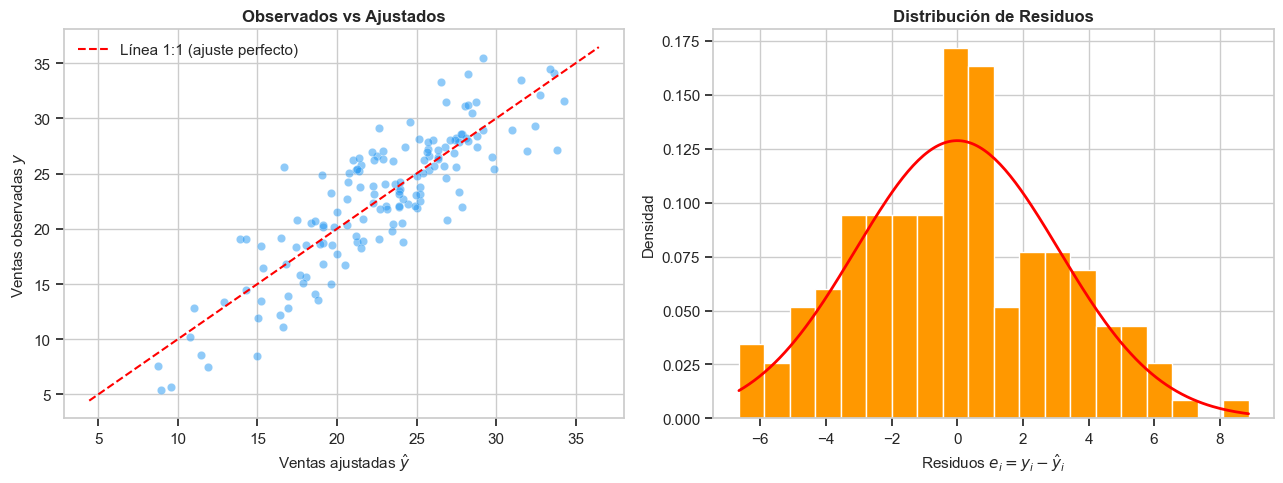

In [13]:
# ─── Visualización: ajuste del modelo ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Observados vs Ajustados
axes[0].scatter(y_hat, y, alpha=0.5, color='#2196F3', edgecolors='white', linewidths=0.3)
lim = [min(y.min(), y_hat.min()) - 1, max(y.max(), y_hat.max()) + 1]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Línea 1:1 (ajuste perfecto)')
axes[0].set_xlabel('Ventas ajustadas $\\hat{y}$', fontsize=11)
axes[0].set_ylabel('Ventas observadas $y$', fontsize=11)
axes[0].set_title('Observados vs Ajustados', fontsize=12, fontweight='bold')
axes[0].legend()

# Distribución de residuos
axes[1].hist(e, bins=20, color='#FF9800', edgecolor='white', density=True)
xr = np.linspace(e.min(), e.max(), 200)
axes[1].plot(xr, stats.norm.pdf(xr, 0, e.std()), 'r-', linewidth=2)
axes[1].set_xlabel('Residuos $e_i = y_i - \\hat{y}_i$', fontsize=11)
axes[1].set_ylabel('Densidad', fontsize=11)
axes[1].set_title('Distribución de Residuos', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 4. Propiedades del Estimador MCO

### 4.1. Insesgamiento

Bajo los supuestos 1–3 (linealidad, exogeneidad, rango completo):

$$E[\hat{\boldsymbol{\beta}}_{\text{MCO}}] = \boldsymbol{\beta}$$

**Demostración:**

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T(\mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}) = \boldsymbol{\beta} + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\boldsymbol{\varepsilon}$$

Tomando esperanza condicional en $\mathbf{X}$:

$$E[\hat{\boldsymbol{\beta}} \mid \mathbf{X}] = \boldsymbol{\beta} + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T \underbrace{E[\boldsymbol{\varepsilon} \mid \mathbf{X}]}_{= \mathbf{0}} = \boldsymbol{\beta} \checkmark$$

### 4.2. Matriz de varianza-covarianza

Bajo los supuestos 1–5:

$$\text{Var}(\hat{\boldsymbol{\beta}} \mid \mathbf{X}) = \sigma^2 (\mathbf{X}^T\mathbf{X})^{-1}$$

La varianza de cada $\hat{\beta}_j$ es el $j$-ésimo elemento diagonal, y la covarianza entre $\hat{\beta}_j$ y $\hat{\beta}_l$ es el elemento $(j,l)$. Los **errores estándar** son:

$$\text{se}(\hat{\beta}_j) = \hat{\sigma}\sqrt{[(\mathbf{X}^T\mathbf{X})^{-1}]_{jj}}$$

### 4.3. Teorema de Gauss-Markov (MELI / BLUE)

> Bajo los supuestos 1–5, el estimador MCO es el **Mejor Estimador Lineal Insesgado** (MELI), es decir, entre todos los estimadores lineales e insesgados de $\boldsymbol{\beta}$, el MCO tiene la **menor varianza**.

MELI = BLUE (*Best Linear Unbiased Estimator*).

Esto significa que ningún otro estimador lineal e insesgado puede tener errores estándar más pequeños. Si adicionalmente se cumple el supuesto 6 (normalidad), entonces MCO es el estimador de mínima varianza entre **todos** los estimadores insesgados (no solo lineales).

### 4.4. Consistencia

Con muestras grandes ($n \to \infty$), $\hat{\boldsymbol{\beta}} \xrightarrow{p} \boldsymbol{\beta}$ bajo condiciones de regularidad estándar. El estimador es también asintóticamente normal:

$$\sqrt{n}(\hat{\boldsymbol{\beta}} - \boldsymbol{\beta}) \xrightarrow{d} \mathcal{N}(\mathbf{0},\, \sigma^2 \mathbf{Q}^{-1})$$

donde $\mathbf{Q} = \text{plim}\,\frac{1}{n}\mathbf{X}^T\mathbf{X}$.

In [15]:
# ─── Matriz de varianza-covarianza de β̂ ────────────────────────────────────
Var_beta_hat = sigma2_hat * XtX_inv

print("Matriz de varianza-covarianza de β̂  (Var(β̂) = σ² (X'X)⁻¹):")
df_var = pd.DataFrame(Var_beta_hat,
                      columns=['const','TV','Radio','Digital'],
                      index=['const','TV','Radio','Digital'])
display(df_var.map(lambda v: f"{v:.6f}"))

# Errores estándar de los coeficientes
se_beta = np.sqrt(np.diag(Var_beta_hat))
print("\nErrores estándar de los coeficientes:")
for nombre, b, se in zip(nombres, beta_hat, se_beta):
    print(f"  {nombre:<20} β̂ = {b:.5f}   SE = {se:.5f}")

Matriz de varianza-covarianza de β̂  (Var(β̂) = σ² (X'X)⁻¹):


,const,TV,Radio,Digital
const,0.806676,-0.001466,-0.010915,-0.004362
TV,-0.001466,0.000009,-0.000002,0.000004
Radio,-0.010915,-0.000002,0.000386,0.000005
Digital,-0.004362,0.000004,0.000005,0.000074



Errores estándar de los coeficientes:
  Intercepto (β₀)      β̂ = 5.47601   SE = 0.89815
  TV (β₁)              β̂ = 0.04215   SE = 0.00302
  Radio (β₂)           β̂ = 0.17457   SE = 0.01964
  Digital (β₃)         β̂ = 0.12336   SE = 0.00862


Verificación de insesgamiento (simulación de Monte Carlo, 2000 réplicas):
Parámetro         β verdadero   Promedio β̂       Sesgo
-------------------------------------------------------
  β_0  Intercepto (β₀)        5.0000        4.9657   -0.034276
  β_1  TV (β₁)           0.0450        0.0450    0.000037
  β_2  Radio (β₂)        0.1800        0.1806    0.000554
  β_3  Digital (β₃)        0.1200        0.1201    0.000133


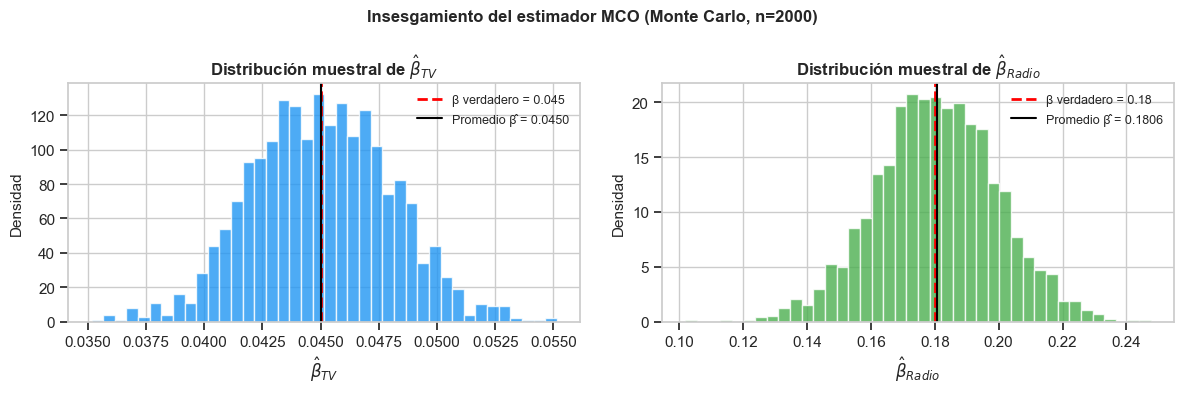

In [16]:
# ─── Simulación Monte Carlo: verificar insesgamiento del estimador ──────────
# Repetimos la estimación con diferentes muestras y verificamos que el promedio
# de los estimadores converge a los verdaderos parámetros

beta_verdadero = np.array([5.0, 0.045, 0.18, 0.12])
n_sim          = 2000
beta_mc        = np.zeros((n_sim, 4))

for s in range(n_sim):
    np.random.seed(s)
    TV_s      = np.random.uniform(10, 300, n)
    Radio_s   = np.random.uniform(5,  50,  n)
    Digital_s = np.random.uniform(0,  100, n)
    eps_s     = np.random.normal(0,   3,   n)
    y_s       = 5 + 0.045*TV_s + 0.18*Radio_s + 0.12*Digital_s + eps_s
    X_s       = np.column_stack([np.ones(n), TV_s, Radio_s, Digital_s])
    beta_mc[s] = np.linalg.solve(X_s.T @ X_s, X_s.T @ y_s)

print("Verificación de insesgamiento (simulación de Monte Carlo, 2000 réplicas):")
print(f"{'Parámetro':<15}  {'β verdadero':>12}  {'Promedio β̂':>12}  {'Sesgo':>10}")
print("-" * 55)
for j, (bv, bprom) in enumerate(zip(beta_verdadero, beta_mc.mean(axis=0))):
    sesgo = bprom - bv
    print(f"  β_{j}  {nombres[j]:<10}  {bv:>12.4f}  {bprom:>12.4f}  {sesgo:>10.6f}")

# Visualización de la distribución de β̂₁ (TV)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, j, col, nm in zip(axes, [1, 2], ['#2196F3', '#4CAF50'], ['TV', 'Radio']):
    ax.hist(beta_mc[:, j], bins=40, density=True, color=col, edgecolor='white', alpha=0.8)
    ax.axvline(beta_verdadero[j], color='red', linewidth=2, linestyle='--',
               label=f'β verdadero = {beta_verdadero[j]}')
    ax.axvline(beta_mc[:, j].mean(), color='black', linewidth=1.5, linestyle='-',
               label=f'Promedio β̂ = {beta_mc[:,j].mean():.4f}')
    ax.set_xlabel(f'$\\hat{{\\beta}}_{{{nm}}}$', fontsize=12)
    ax.set_ylabel('Densidad', fontsize=11)
    ax.set_title(f'Distribución muestral de $\\hat{{\\beta}}_{{{nm}}}$', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Insesgamiento del estimador MCO (Monte Carlo, n=2000)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Estimación de Máxima Verosimilitud (MV)

### 5.1. Función de verosimilitud

Bajo el supuesto 6 ($\boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^2\mathbf{I}_n)$), cada $y_i$ se distribuye de forma independiente:

$$y_i \mid \mathbf{x}_i \sim \mathcal{N}(\mathbf{x}_i^T\boldsymbol{\beta},\, \sigma^2)$$

La función de densidad conjunta (verosimilitud) es:

$$L(\boldsymbol{\beta}, \sigma^2 \mid \mathbf{y}, \mathbf{X}) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(y_i - \mathbf{x}_i^T\boldsymbol{\beta})^2}{2\sigma^2}\right)$$

### 5.2. Log-verosimilitud

Tomando logaritmo (la función es monótona creciente, así que el máximo es el mismo):

$$\ell(\boldsymbol{\beta}, \sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2}(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

### 5.3. Estimadores MV

**Para $\boldsymbol{\beta}$:** Maximizar $\ell$ respecto a $\boldsymbol{\beta}$ equivale a minimizar $(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$, que es exactamente el problema de MCO. Por tanto:

$$\boxed{\hat{\boldsymbol{\beta}}_{\text{MV}} = \hat{\boldsymbol{\beta}}_{\text{MCO}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}}$$

**Para $\sigma^2$:** Derivando respecto a $\sigma^2$ e igualando a cero:

$$\hat{\sigma}^2_{\text{MV}} = \frac{1}{n}\sum_{i=1}^n e_i^2 = \frac{\mathbf{e}^T\mathbf{e}}{n}$$

> **Nota:** El estimador MV de $\sigma^2$ divide entre $n$ (sesgado), mientras que el estimador MCO divide entre $n-k-1$ (insesgado). En la práctica se usa el estimador insesgado $s^2 = \frac{\mathbf{e}^T\mathbf{e}}{n-k-1}$.

### 5.4. Log-verosimilitud maximizada

Sustituyendo los estimadores en $\ell$:

$$\hat{\ell} = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln\!\left(\frac{\mathbf{e}^T\mathbf{e}}{n}\right) - \frac{n}{2}$$

Esta expresión se usa para construir criterios de información (AIC, BIC) y pruebas de razón de verosimilitud.

In [17]:
# ─── Cálculo manual de la log-verosimilitud ─────────────────────────────────
sigma2_MV = (e @ e) / n           # estimador MV (sesgado)
sigma2_MCO = (e @ e) / (n-k-1)   # estimador MCO (insesgado)

# Log-verosimilitud maximizada
ll_max = (-n/2) * np.log(2 * np.pi) \
         - (n/2) * np.log(sigma2_MV) \
         - n/2

print("Estimadores de varianza:")
print(f"  MV  (sesgado,   ÷ n):     σ̂²_MV  = {sigma2_MV:.4f}")
print(f"  MCO (insesgado, ÷ n-k-1): σ̂²_MCO = {sigma2_MCO:.4f}")
print()
print(f"Log-verosimilitud maximizada: {ll_max:.4f}")
print(f"Verificación con statsmodels: {modelo_sm.llf:.4f}")
print()
print(f"AIC = -2·ℓ + 2·(k+2)  = {modelo_sm.aic:.4f}")
print(f"BIC = -2·ℓ + (k+2)·ln(n) = {modelo_sm.bic:.4f}")
print("(k+2 = k predictores + intercepto + σ²)")

Estimadores de varianza:
  MV  (sesgado,   ÷ n):     σ̂²_MV  = 9.6000
  MCO (insesgado, ÷ n-k-1): σ̂²_MCO = 9.8630

Log-verosimilitud maximizada: -382.4729
Verificación con statsmodels: -382.4729

AIC = -2·ℓ + 2·(k+2)  = 772.9458
BIC = -2·ℓ + (k+2)·ln(n) = 784.9883
(k+2 = k predictores + intercepto + σ²)


C:\Users\natalia.acevedop\AppData\Local\Temp\ipykernel_17220\1971124696.py:24: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\natalia.acevedop\AppData\Local\Temp\ipykernel_17220\1971124696.py:24: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\natalia.acevedop\AppData\Local\Temp\ipykernel_17220\1971124696.py:24: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\natalia.acevedop\AppData\Local\Temp\ipykernel_17220\1971124696.py:24: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\natalia.acevedop\Documents\GitHub\MisCursos\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\natalia.acevedop\Documents\GitHub\MisCursos\.venv\Lib\site-packages\IPython\

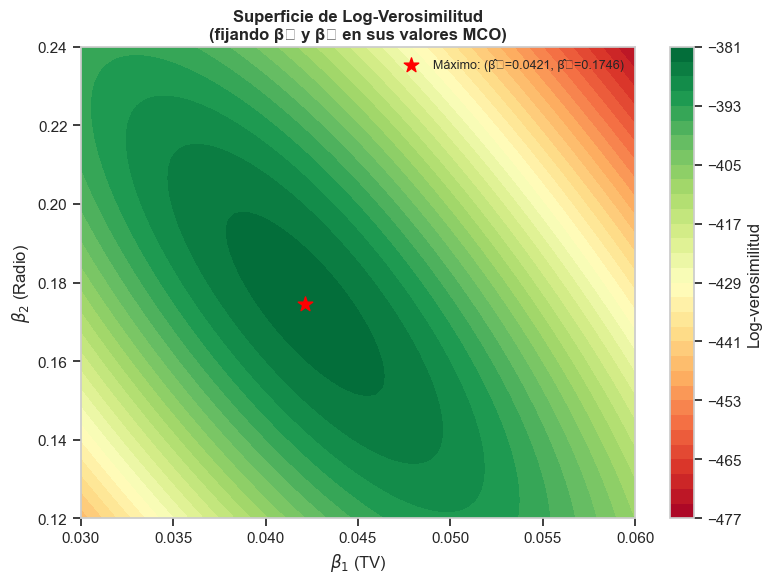

In [18]:
# ─── Visualización de la superficie de log-verosimilitud (β₁ vs β₂) ─────────
b1_range = np.linspace(0.03, 0.06, 80)
b2_range = np.linspace(0.12, 0.24, 80)
B1, B2   = np.meshgrid(b1_range, b2_range)

LL = np.zeros_like(B1)
for i in range(B1.shape[0]):
    for j in range(B1.shape[1]):
        b_temp      = np.array([beta_hat[0], B1[i,j], B2[i,j], beta_hat[3]])
        e_temp      = y - X @ b_temp
        sigma2_temp = (e_temp @ e_temp) / n
        if sigma2_temp > 0:
            LL[i,j] = (-n/2)*np.log(2*np.pi) - (n/2)*np.log(sigma2_temp) - n/2

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contourf(B1, B2, LL, levels=30, cmap='RdYlGn')
plt.colorbar(cs, ax=ax, label='Log-verosimilitud')
ax.scatter(beta_hat[1], beta_hat[2], color='red', s=120, zorder=5,
           marker='*', label=f'Maximo: (b1={beta_hat[1]:.4f}, b2={beta_hat[2]:.4f})')
ax.set_xlabel('$\\beta_1$ (TV)', fontsize=12)
ax.set_ylabel('$\\beta_2$ (Radio)', fontsize=12)
ax.set_title('Superficie de Log-Verosimilitud\n(fijando β₀ y β₃ en sus valores MCO)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---

## 6. Análisis de Varianza (ANOVA)

### 6.1. Descomposición de la variabilidad total

La variabilidad total de $y$ se descompone en dos partes:

$$\underbrace{\sum_{i=1}^n (y_i - \bar{y})^2}_{\text{SCT}} = \underbrace{\sum_{i=1}^n (\hat{y}_i - \bar{y})^2}_{\text{SCR (Regresión)}} + \underbrace{\sum_{i=1}^n (y_i - \hat{y}_i)^2}_{\text{SCE (Error)}}$$

$$\text{SCT} = \text{SCR} + \text{SCE}$$

En notación matricial:

$$\mathbf{y}^T(\mathbf{I} - \mathbf{J}/n)\mathbf{y} = \mathbf{y}^T(\mathbf{H} - \mathbf{J}/n)\mathbf{y} + \mathbf{y}^T(\mathbf{I} - \mathbf{H})\mathbf{y}$$

donde $\mathbf{J} = \mathbf{1}\mathbf{1}^T$ y $\mathbf{H}$ es la matriz sombrero.

### 6.2. Tabla ANOVA de la regresión

| Fuente | Suma de cuadrados | Grados de libertad | Cuadrado medio | Estadístico F |
|--------|------------------:|-------------------:|---------------:|:-------------:|
| Regresión | $\text{SCR} = \sum(\hat{y}_i - \bar{y})^2$ | $k$ | $\text{CMR} = \text{SCR}/k$ | $F = \text{CMR}/\text{CME}$ |
| Error | $\text{SCE} = \sum(y_i - \hat{y}_i)^2$ | $n - k - 1$ | $\text{CME} = \text{SCE}/(n-k-1)$ | |
| **Total** | **$\text{SCT} = \sum(y_i - \bar{y})^2$** | **$n - 1$** | | |

El estadístico $F$ bajo $H_0: \beta_1 = \beta_2 = \cdots = \beta_k = 0$ sigue una distribución $F_{k,\, n-k-1}$.

### 6.3. Interpretación empresarial

En nuestro ejemplo de publicidad:
- **SCR** = variabilidad de las ventas *explicada* por el presupuesto de publicidad.
- **SCE** = variabilidad *no explicada* (factores como estacionalidad, competencia, etc.).
- Un $F$ grande indica que el modelo en conjunto es estadísticamente significativo.

In [19]:
# ─── Tabla ANOVA manual ──────────────────────────────────────────────────────
y_bar = y.mean()

SCT = np.sum((y - y_bar)**2)                    # Suma de cuadrados total
SCR = np.sum((y_hat - y_bar)**2)                # Suma de cuadrados de la regresión
SCE = np.sum(e**2)                              # Suma de cuadrados del error

gl_R = k                                        # grados de libertad: regresión
gl_E = n - k - 1                                # grados de libertad: error
gl_T = n - 1                                    # grados de libertad: total

CMR = SCR / gl_R                                # Cuadrado medio de la regresión
CME = SCE / gl_E                                # Cuadrado medio del error

F_stat  = CMR / CME
p_valor = 1 - stats.f.cdf(F_stat, gl_R, gl_E)

anova_table = pd.DataFrame({
    'Fuente':           ['Regresión', 'Error', 'Total'],
    'SC':               [SCR, SCE, SCT],
    'gl':               [gl_R, gl_E, gl_T],
    'CM':               [CMR, CME, np.nan],
    'F':                [F_stat, np.nan, np.nan],
    'p-valor':          [p_valor, np.nan, np.nan]
})
anova_table = anova_table.set_index('Fuente')

print("Tabla ANOVA de la Regresión")
print("=" * 65)
display(anova_table.style.format({
    'SC': '{:.4f}', 'gl': '{:.0f}', 'CM': '{:.4f}',
    'F': '{:.4f}', 'p-valor': '{:.6f}'
}, na_rep='—'))
print(f"\nF crítico (α=0.05): {stats.f.ppf(0.95, gl_R, gl_E):.4f}")
print(f"F calculado:        {F_stat:.4f}")
print(f"\n→ Conclusión: el modelo {'es' if p_valor < 0.05 else 'NO es'} globalmente significativo (α=0.05)")

Tabla ANOVA de la Regresión


,SC,gl,CM,F,p-valor
Fuente,,,,,
Regresión,4244.4749,3,1414.8250,143.4478,0.000000
Error,1439.9978,146,9.8630,—,—
Total,5684.4727,149,—,—,—



F crítico (α=0.05): 2.6666
F calculado:        143.4478

→ Conclusión: el modelo es globalmente significativo (α=0.05)


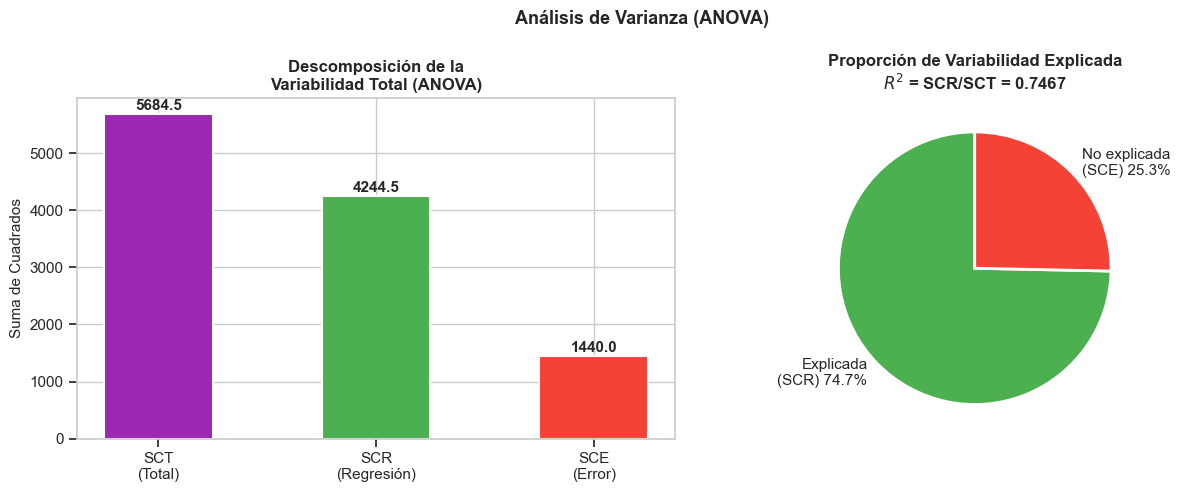

In [20]:
# ─── Visualización de la descomposición ANOVA ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico de barras de las sumas de cuadrados
categorias = ['SCT\n(Total)', 'SCR\n(Regresión)', 'SCE\n(Error)']
valores     = [SCT, SCR, SCE]
colores_b   = ['#9C27B0', '#4CAF50', '#F44336']

bars = axes[0].bar(categorias, valores, color=colores_b, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Suma de Cuadrados', fontsize=11)
axes[0].set_title('Descomposición de la\nVariabilidad Total (ANOVA)', fontsize=12, fontweight='bold')

# Gráfico de pastel: proporción explicada vs no explicada
props  = [SCR/SCT * 100, SCE/SCT * 100]
labels = [f'Explicada\n(SCR) {props[0]:.1f}%', f'No explicada\n(SCE) {props[1]:.1f}%']
axes[1].pie(props, labels=labels, colors=['#4CAF50', '#F44336'],
            autopct='', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title(f'Proporción de Variabilidad Explicada\n$R^2$ = SCR/SCT = {SCR/SCT:.4f}',
                  fontsize=12, fontweight='bold')

plt.suptitle('Análisis de Varianza (ANOVA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 7. Bondad de Ajuste

### 7.1. Coeficiente de determinación $R^2$

El $R^2$ mide la proporción de la variabilidad total de $y$ que es explicada por el modelo:

$$R^2 = \frac{\text{SCR}}{\text{SCT}} = 1 - \frac{\text{SCE}}{\text{SCT}} \in [0, 1]$$

**Interpretación:** Un $R^2 = 0.85$ significa que el **85% de la variabilidad** de las ventas es explicado por el gasto en publicidad.

**Limitaciones del $R^2$:**
- Siempre aumenta (o permanece igual) al agregar más regresores, incluso irrelevantes.
- No mide si el modelo es correcto, solo la proporción lineal explicada.
- Puede ser alto con datos correlacionados sin causalidad alguna.

### 7.2. $R^2$ ajustado

El $R^2$ ajustado penaliza la adición de variables innecesarias:

$$\bar{R}^2 = 1 - \frac{\text{SCE}/(n-k-1)}{\text{SCT}/(n-1)} = 1 - (1 - R^2)\frac{n-1}{n-k-1}$$

Propiedades:
- $\bar{R}^2 \leq R^2$ siempre.
- $\bar{R}^2$ puede ser negativo si el modelo es muy malo.
- Solo aumenta si la nueva variable mejora el ajuste más de lo esperado por azar.
- Es el criterio correcto para comparar modelos con diferente número de predictores.

### 7.3. Error estándar de la regresión (RMSE)

$$s = \sqrt{\text{CME}} = \sqrt{\frac{\text{SCE}}{n-k-1}}$$

Mide el error promedio de predicción en las **unidades originales de $y$**. Es más interpretable que el $R^2$ para comunicar la precisión del modelo.

### 7.4. Criterios de información (AIC y BIC)

Para comparar modelos con diferente número de parámetros:

$$\text{AIC} = -2\hat{\ell} + 2p, \qquad \text{BIC} = -2\hat{\ell} + p\ln(n)$$

donde $p = k + 2$ es el número total de parámetros ($k+1$ coeficientes más $\sigma^2$). Se prefiere el modelo con **menor AIC/BIC**. BIC penaliza más fuertemente la complejidad del modelo.

In [21]:
# ─── Cálculo de métricas de bondad de ajuste ─────────────────────────────────
R2     = SCR / SCT
R2_adj = 1 - (SCE/(n-k-1)) / (SCT/(n-1))
RMSE   = np.sqrt(CME)
MAE    = np.mean(np.abs(e))

print("Métricas de bondad de ajuste")
print("=" * 42)
print(f"  R²            = {R2:.6f}")
print(f"  R² ajustado   = {R2_adj:.6f}")
print(f"  RMSE (s)      = {RMSE:.4f}  (unidades: miles de ventas)")
print(f"  MAE           = {MAE:.4f}")
print(f"  AIC           = {modelo_sm.aic:.4f}")
print(f"  BIC           = {modelo_sm.bic:.4f}")
print()
print(f"Verificación con statsmodels:")
print(f"  R² (sm)       = {modelo_sm.rsquared:.6f}")
print(f"  R² adj (sm)   = {modelo_sm.rsquared_adj:.6f}")

Métricas de bondad de ajuste
  R²            = 0.746679
  R² ajustado   = 0.741474
  RMSE (s)      = 3.1405  (unidades: miles de ventas)
  MAE           = 2.4890
  AIC           = 772.9458
  BIC           = 784.9883

Verificación con statsmodels:
  R² (sm)       = 0.746679
  R² adj (sm)   = 0.741474


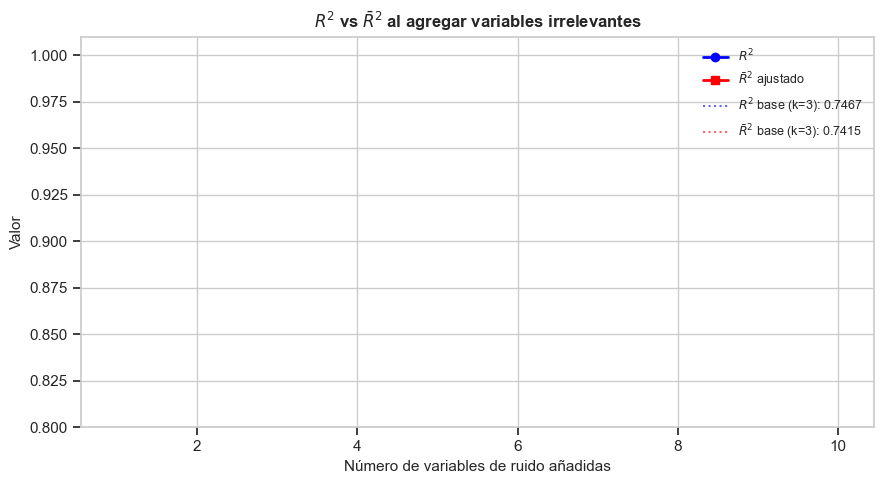

Nota: R² nunca disminuye, pero R² ajustado sí puede caer al agregar ruido.


In [22]:
# ─── Efecto del número de variables en R² vs R² ajustado ────────────────────
# Mostramos por qué R² siempre crece con más variables, mientras R² ajustado no

np.random.seed(99)
# Variables irrelevantes (ruido puro)
n_vars   = 10
ruido    = np.random.randn(n, n_vars)

r2_list  = []
r2a_list = []
k_list   = list(range(1, n_vars + 1))

for nv in k_list:
    X_tmp = np.column_stack([
        np.ones(n),
        df[['TV', 'Radio', 'Digital']].values,      # variables reales
        ruido[:, :nv]                                # variables de ruido
    ])
    b_tmp  = np.linalg.solve(X_tmp.T @ X_tmp, X_tmp.T @ y)
    y_hat_tmp = X_tmp @ b_tmp
    e_tmp  = y - y_hat_tmp
    k_tmp  = 3 + nv

    scr_tmp = np.sum((y_hat_tmp - y_bar)**2)
    sce_tmp = np.sum(e_tmp**2)
    sct_tmp = SCT

    r2_tmp  = scr_tmp / sct_tmp
    r2a_tmp = 1 - (sce_tmp/(n - k_tmp - 1)) / (sct_tmp/(n - 1))

    r2_list.append(r2_tmp)
    r2a_list.append(r2a_tmp)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_list, r2_list,  'b-o', linewidth=2, markersize=6, label='$R^2$')
ax.plot(k_list, r2a_list, 'r-s', linewidth=2, markersize=6, label='$\\bar{R}^2$ ajustado')
ax.axhline(R2,     color='blue',   linestyle=':', alpha=0.6, label=f'$R^2$ base (k=3): {R2:.4f}')
ax.axhline(R2_adj, color='red',    linestyle=':', alpha=0.6, label=f'$\\bar{{R}}^2$ base (k=3): {R2_adj:.4f}')
ax.set_xlabel('Número de variables de ruido añadidas', fontsize=11)
ax.set_ylabel('Valor', fontsize=11)
ax.set_title('$R^2$ vs $\\bar{R}^2$ al agregar variables irrelevantes', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.8, 1.01)
plt.tight_layout()
plt.show()
print("Nota: R² nunca disminuye, pero R² ajustado sí puede caer al agregar ruido.")

---

## 8. Pruebas de Hipótesis Asociadas a la Regresión

### 8.1. Prueba $t$ para coeficientes individuales

Para cada coeficiente $\beta_j$ se contrasta:

$$H_0: \beta_j = 0 \quad \text{vs} \quad H_1: \beta_j \neq 0$$

(o también pruebas unilaterales: $H_1: \beta_j > 0$ o $H_1: \beta_j < 0$)

El estadístico de prueba es:

$$t_j = \frac{\hat{\beta}_j - 0}{\text{se}(\hat{\beta}_j)} = \frac{\hat{\beta}_j}{\hat{\sigma}\sqrt{[(\mathbf{X}^T\mathbf{X})^{-1}]_{jj}}} \sim t_{n-k-1}$$

bajo $H_0$ y los supuestos 1–6.

**Regla de decisión (bilateral, nivel $\alpha$):**
- Rechazar $H_0$ si $|t_j| > t_{\alpha/2,\, n-k-1}$
- O equivalentemente si $p\text{-valor} < \alpha$

### 8.2. Intervalo de confianza para $\beta_j$

$$\hat{\beta}_j \pm t_{\alpha/2,\, n-k-1} \cdot \text{se}(\hat{\beta}_j)$$

Captura el valor verdadero $\beta_j$ con probabilidad $1 - \alpha$ bajo muestreo repetido.

### 8.3. Prueba $F$ global

Contrasta la utilidad conjunta de todos los predictores:

$$H_0: \beta_1 = \beta_2 = \cdots = \beta_k = 0 \quad \text{vs} \quad H_1: \text{al menos un } \beta_j \neq 0$$

$$F = \frac{\text{SCR}/k}{\text{SCE}/(n-k-1)} = \frac{\text{CMR}}{\text{CME}} \sim F_{k,\, n-k-1} \quad \text{bajo } H_0$$

Esta es exactamente la $F$ de la tabla ANOVA (Sección 6). Un $F$ grande indica que la regresión explica significativamente más variabilidad que un modelo solo con intercepto.

### 8.4. Prueba $F$ para restricciones lineales (prueba parcial)

Para contrastar si un **subconjunto** de $q$ coeficientes es conjuntamente cero:

$$H_0: \boldsymbol{R}\boldsymbol{\beta} = \mathbf{r} \quad \text{(q restricciones lineales)}$$

El estadístico es:

$$F = \frac{(\mathbf{R}\hat{\boldsymbol{\beta}} - \mathbf{r})^T [\hat{\sigma}^2\mathbf{R}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{R}^T]^{-1}(\mathbf{R}\hat{\boldsymbol{\beta}} - \mathbf{r})}{q} \sim F_{q,\, n-k-1}$$

Equivalentemente: $F = \frac{(\text{SCE}_R - \text{SCE}_C)/q}{\text{SCE}_C/(n-k-1)}$, donde $\text{SCE}_R$ y $\text{SCE}_C$ son las sumas de cuadrados del error del modelo restringido y del completo.

In [23]:
# ─── Pruebas t para coeficientes individuales (cálculo manual) ──────────────
t_stats = beta_hat / se_beta
p_vals  = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n-k-1))
t_crit  = stats.t.ppf(0.975, df=n-k-1)   # α=0.05, bilateral

# Intervalos de confianza al 95%
CI_low  = beta_hat - t_crit * se_beta
CI_high = beta_hat + t_crit * se_beta

resultados = pd.DataFrame({
    'Coeficiente':  nombres,
    'β̂':           beta_hat,
    'SE':           se_beta,
    't':            t_stats,
    'p-valor':      p_vals,
    'IC 95% Inf':   CI_low,
    'IC 95% Sup':   CI_high,
    'Significativo': ['✔ Sí' if p < 0.05 else '✗ No' for p in p_vals]
}).set_index('Coeficiente')

print("Pruebas t individuales (α = 0.05, t crítico bilateral = {:.4f})".format(t_crit))
print("=" * 75)
display(resultados.style.format({
    'β̂': '{:.5f}', 'SE': '{:.5f}', 't': '{:.4f}',
    'p-valor': '{:.6f}', 'IC 95% Inf': '{:.5f}', 'IC 95% Sup': '{:.5f}'
}))

Pruebas t individuales (α = 0.05, t crítico bilateral = 1.9763)


,β̂,SE,t,p-valor,IC 95% Inf,IC 95% Sup,Significativo
Coeficiente,,,,,,,
Intercepto (β₀),5.47601,0.89815,6.0970,0.000000,3.70095,7.25107,✔ Sí
TV (β₁),0.04215,0.00302,13.9493,0.000000,0.03618,0.04812,✔ Sí
Radio (β₂),0.17457,0.01964,8.8874,0.000000,0.13575,0.21339,✔ Sí
Digital (β₃),0.12336,0.00862,14.3056,0.000000,0.10632,0.14040,✔ Sí


C:\Users\natalia.acevedop\AppData\Local\Temp\ipykernel_17220\3354103470.py:17: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\natalia.acevedop\AppData\Local\Temp\ipykernel_17220\3354103470.py:17: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\natalia.acevedop\AppData\Local\Temp\ipykernel_17220\3354103470.py:17: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\natalia.acevedop\AppData\Local\Temp\ipykernel_17220\3354103470.py:17: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\natalia.acevedop\Documents\GitHub\MisCursos\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\natalia.acevedop\Documents\GitHub\MisCursos\.venv\Lib\site-packages\IPython\

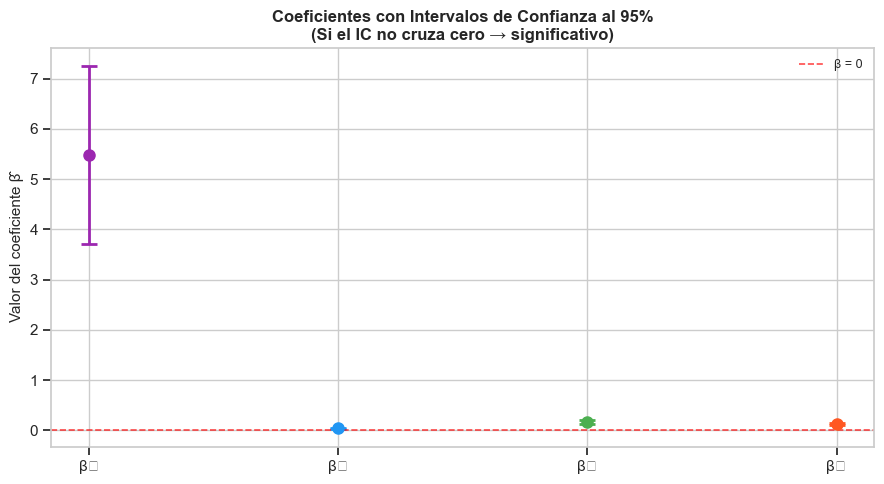

In [24]:
# ─── Visualización de coeficientes con intervalos de confianza ───────────────
fig, ax = plt.subplots(figsize=(9, 5))

colores_ic = ['#9C27B0', '#2196F3', '#4CAF50', '#FF5722']
x_pos = np.arange(4)

for i, (nombre, bv, lo, hi, col) in enumerate(zip(nombres, beta_hat, CI_low, CI_high, colores_ic)):
    ax.errorbar(i, bv, yerr=[[bv - lo], [hi - bv]],
                fmt='o', color=col, capsize=6, capthick=2, elinewidth=2, markersize=8)

ax.axhline(0, color='red', linewidth=1.2, linestyle='--', alpha=0.7, label='β = 0')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Intercepto', 'TV', 'Radio', 'Digital'], fontsize=11)
ax.set_ylabel('Valor del coeficiente $\\hat{\\beta}$', fontsize=11)
ax.set_title('Coeficientes con Intervalos de Confianza al 95%\n(Si el IC no cruza cero → significativo)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [25]:
# ─── Prueba F global (verificación) ─────────────────────────────────────────
print("Prueba F Global")
print("=" * 40)
print(f"H₀: β₁ = β₂ = β₃ = 0  (ningún canal de publicidad tiene efecto)")
print(f"H₁: al menos un βⱼ ≠ 0")
print()
print(f"  F calculado      = {F_stat:.4f}")
print(f"  F crítico (α=0.05, {gl_R}, {gl_E}) = {stats.f.ppf(0.95, gl_R, gl_E):.4f}")
print(f"  p-valor          = {p_valor:.2e}")
print()
print(f"  Decisión: {'Rechazar H₀' if p_valor < 0.05 else 'No rechazar H₀'} → el modelo en conjunto {'ES' if p_valor < 0.05 else 'NO ES'} significativo.")

Prueba F Global
H₀: β₁ = β₂ = β₃ = 0  (ningún canal de publicidad tiene efecto)
H₁: al menos un βⱼ ≠ 0

  F calculado      = 143.4478
  F crítico (α=0.05, 3, 146) = 2.6666
  p-valor          = 0.00e+00

  Decisión: Rechazar H₀ → el modelo en conjunto ES significativo.


In [26]:
# ─── Prueba F parcial: ¿los canales Radio y Digital son conjuntamente útiles? ─
# Modelo completo (C): Ventas ~ TV + Radio + Digital
# Modelo restringido (R): Ventas ~ TV  (sin Radio ni Digital)

X_R = X[:, [0, 1]]                           # solo intercepto y TV
b_R = np.linalg.solve(X_R.T @ X_R, X_R.T @ y)
e_R = y - X_R @ b_R
SCE_R = e_R @ e_R                             # SCE modelo restringido
SCE_C = e @ e                                 # SCE modelo completo

q = 2                                         # número de restricciones
F_parcial = ((SCE_R - SCE_C) / q) / (SCE_C / (n - k - 1))
p_parcial  = 1 - stats.f.cdf(F_parcial, q, n - k - 1)

print("Prueba F Parcial")
print("=" * 55)
print("H₀: β_Radio = β_Digital = 0  (Radio y Digital no aportan)")
print("H₁: al menos uno de β_Radio, β_Digital ≠ 0")
print()
print(f"  SCE restringido (solo TV) = {SCE_R:.4f}")
print(f"  SCE completo              = {SCE_C:.4f}")
print(f"  Diferencia (SCE_R - SCE_C)= {SCE_R - SCE_C:.4f}")
print()
print(f"  F parcial = {F_parcial:.4f}")
print(f"  p-valor   = {p_parcial:.2e}")
print()
print(f"  Decisión: {'Rechazar H₀' if p_parcial < 0.05 else 'No rechazar H₀'} → agregar Radio y Digital {'MEJORA' if p_parcial < 0.05 else 'NO mejora'} el modelo.")

Prueba F Parcial
H₀: β_Radio = β_Digital = 0  (Radio y Digital no aportan)
H₁: al menos uno de β_Radio, β_Digital ≠ 0

  SCE restringido (solo TV) = 4159.5027
  SCE completo              = 1439.9978
  Diferencia (SCE_R - SCE_C)= 2719.5049

  F parcial = 137.8640
  p-valor   = 0.00e+00

  Decisión: Rechazar H₀ → agregar Radio y Digital MEJORA el modelo.


In [27]:
# ─── Resumen completo del modelo con statsmodels ────────────────────────────
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     143.4
Date:              mié., 27 may. 2026   Prob (F-statistic):           2.47e-43
Time:                        11:08:17   Log-Likelihood:                -382.47
No. Observations:                 150   AIC:                             772.9
Df Residuals:                     146   BIC:                             785.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4760      0.898      6.097      0.0

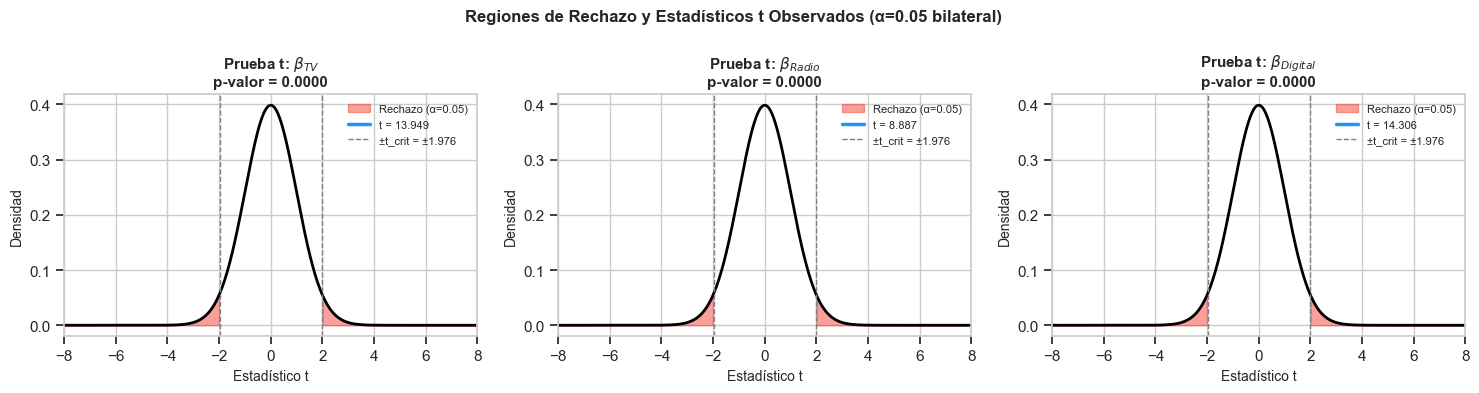

In [28]:
# ─── Visualización de las distribuciones t y regiones de rechazo ─────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vars_plot = [('TV', 1), ('Radio', 2), ('Digital', 3)]

for ax, (var, j) in zip(axes, vars_plot):
    gl_e = n - k - 1
    x    = np.linspace(-8, 8, 500)
    y_t  = stats.t.pdf(x, df=gl_e)

    ax.plot(x, y_t, 'k-', linewidth=2)

    # Región de rechazo (bilateral α=0.05)
    tc = stats.t.ppf(0.975, df=gl_e)
    x_left  = x[x <= -tc]
    x_right = x[x >= tc]
    ax.fill_between(x_left,  stats.t.pdf(x_left,  gl_e), color='#F44336', alpha=0.5, label='Rechazo (α=0.05)')
    ax.fill_between(x_right, stats.t.pdf(x_right, gl_e), color='#F44336', alpha=0.5)

    # Estadístico t observado
    t_obs = t_stats[j]
    ax.axvline(t_obs, color='#2196F3', linewidth=2.5, linestyle='-',
               label=f't = {t_obs:.3f}')
    ax.axvline(-tc, color='gray', linewidth=1, linestyle='--')
    ax.axvline( tc, color='gray', linewidth=1, linestyle='--', label=f'±t_crit = ±{tc:.3f}')

    ax.set_xlabel('Estadístico t', fontsize=10)
    ax.set_ylabel('Densidad', fontsize=10)
    ax.set_title(f'Prueba t: $\\beta_{{{var}}}$\np-valor = {p_vals[j]:.4f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(-8, 8)

plt.suptitle('Regiones de Rechazo y Estadísticos t Observados (α=0.05 bilateral)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Resumen y Mapa Conceptual

| Componente | Fórmula clave | Propósito |
|---|---|---|
| **Modelo** | $\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$ | Especificación |
| **Estimador MCO** | $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ | Ajuste |
| **Varianza del estimador** | $\hat{\sigma}^2(\mathbf{X}^T\mathbf{X})^{-1}$ | Precisión |
| **Estimador MV** | $= \hat{\boldsymbol{\beta}}_{\text{MCO}}$ (bajo normalidad) | Inferencia exacta |
| **Suma de cuadrados** | $\text{SCT} = \text{SCR} + \text{SCE}$ | Descomposición |
| **$R^2$** | $\text{SCR}/\text{SCT}$ | Bondad global |
| **$\bar{R}^2$** | $1 - \frac{\text{SCE}/(n-k-1)}{\text{SCT}/(n-1)}$ | Bondad penalizada |
| **Prueba $t$** | $t_j = \hat{\beta}_j / \text{se}(\hat{\beta}_j) \sim t_{n-k-1}$ | Sig. individual |
| **Prueba $F$** | $F = \text{CMR}/\text{CME} \sim F_{k, n-k-1}$ | Sig. global |

### Flujo de trabajo recomendado

1. **Especificar** el modelo y verificar la teoría económica/empresarial.
2. **Estimar** con MCO y revisar la salida de `statsmodels`.
3. **Verificar supuestos**: residuos vs ajustados, Q-Q, VIF.
4. **Evaluar bondad de ajuste**: $R^2$ ajustado, RMSE, AIC/BIC.
5. **Interpretar** los coeficientes con sus intervalos de confianza.
6. **Decidir** sobre la significancia de variables con pruebas $t$ y $F$ parciales.

> La regresión lineal múltiple es el punto de partida de prácticamente todos los modelos estadísticos avanzados: regresión logística, modelos de datos panel, series de tiempo, machine learning supervisado, etc.